In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)
titanic.drop("Cabin", axis=1, inplace=True)

titanic["Sex"] = LabelEncoder().fit_transform(titanic["Sex"])
titanic["Embarked"] = LabelEncoder().fit_transform(titanic["Embarked"])

X = titanic.drop(["PassengerId", "Name", "Ticket", "Survived"], axis=1)
y = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 7)
Test set shape: (179, 7)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 79.89%


In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train_scaled, y_train)

lda_preds = lda_model.predict(X_test_scaled)

lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Classification Accuracy: {lda_accuracy * 100:.2f}%")

LDA Classification Accuracy: 79.33%


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"k-NN Classification Accuracy: {knn_accuracy * 100:.2f}%")

k-NN Classification Accuracy: 81.01%


In [5]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          79.888268
Linear Discriminant Analysis (LDA)          79.329609
        k-Nearest Neighbors (k-NN)          81.005587


In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_preds = nb_model.predict(X_test_scaled)

nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naive Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naive Bayes Test Accuracy: 78.21%


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_linear.fit(X_train_scaled, y_train)

linear_preds = svm_linear.predict(X_test_scaled)

linear_accuracy = accuracy_score(y_test, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

Linear Kernel SVM Test Accuracy: 77.65%


In [8]:
import pandas as pd

titanic_comparison = pd.DataFrame({
    'Classifier': [
        'Gaussian Naive Bayes (Probabilistic)',
        'Linear Kernel SVM (Maximum-Margin)'
    ],
    'Test Accuracy (%)': [
        nb_accuracy * 100,
        linear_accuracy * 100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")
print(titanic_comparison.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
                          Classifier  Test Accuracy (%)
Gaussian Naive Bayes (Probabilistic)          78.212291
  Linear Kernel SVM (Maximum-Margin)          77.653631


In [9]:
from sklearn.metrics import classification_report

report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Not Survived', 'Survived']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



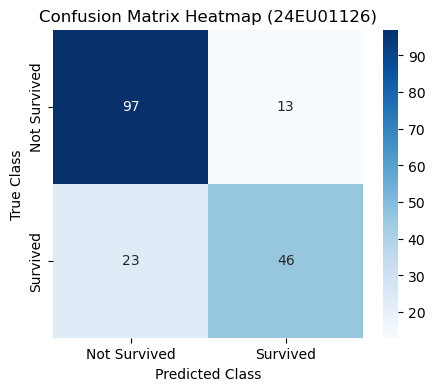

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title("Confusion Matrix Heatmap (24EU01126)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")

plt.show()

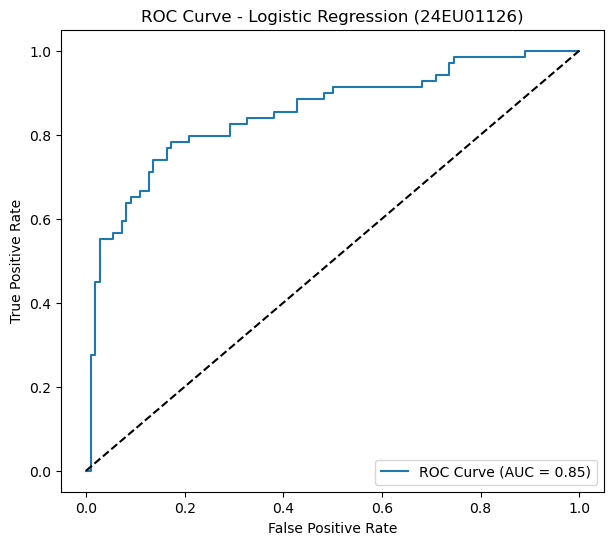

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_score = lr_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.2f})'
)

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (24EU01126)")
plt.legend(loc="lower right")

plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.7709
Fold 2: 0.7865
Fold 3: 0.7809
Fold 4: 0.7640
Fold 5: 0.8202

Mean Accuracy: 78.45%
Standard Deviation: 1.95%
